In [ ]:
#@title Let's check if we are using the GPU. If not, go to **Runtime** $\rightarrow$ **Change runtime type** $\rightarrow$ **T4 GPU**
import sys
if 'google.colab' in sys.modules:
    from IPython import get_ipython
    get_ipython().system('nvidia-smi')

In [ ]:
#@title Install required libraries
import sys
if 'google.colab' in sys.modules:
    from IPython import get_ipython
    get_ipython().system('pip install -qq -U diffusers==0.32.2 transformers==4.49.0 gradio==5.20.1 accelerate==1.5.1 scipy==1.15.2 safetensors==0.5.3 opencv-python controlnet_aux==0.0.9 invisible_watermark>=0.2.0')

/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warnin

dpt_hybrid-midas-501f0c75.pt:   0%|          | 0.00/493M [00:00<?, ?B/s]

/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/controlnet_aux/midas/midas/base_model.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  parameters = 

config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

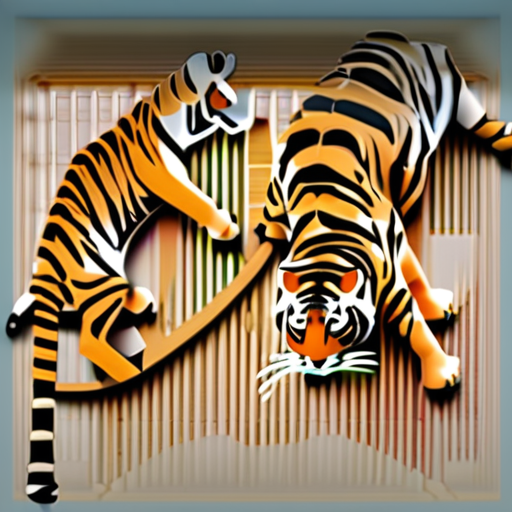

In [ ]:
#@title **Import and download model**
import torch
import requests
from PIL import Image
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel, AutoencoderKL
from controlnet_aux import MidasDetector

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device == "cuda" else torch.float32

# Initialize Depth Estimator
midas = MidasDetector.from_pretrained("lllyasviel/Annotators")

def get_depth_map(image):
    return midas(image)

controlnet = ControlNetModel.from_pretrained(
    "diffusers/controlnet-depth-sdxl-1.0",
    use_safetensors=True,
    torch_dtype=dtype,
    variant="fp16" if device == "cuda" else None,
).to(device)

vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=dtype).to(device)

pipe = StableDiffusionXLControlNetPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    controlnet=controlnet,
    vae=vae,
    use_safetensors=True,
    torch_dtype=dtype,
    variant="fp16" if device == "cuda" else None,
).to(device)

# Load a default image from URL (example image)
url = "http://images.cocodataset.org/val2017/000000039769.jpg"

init_image = Image.open(requests.get(url, stream=True).raw).resize((1024, 1024))

# Example prompts (will be used as defaults in the UI)
prompt = "two tigers"
n_prompt = "bad, deformed, ugly, bad anotomy"

# Optional: generate a sample image to verify the pipeline (this can be commented out)
depth_image = get_depth_map(init_image)
sample_image = pipe(
    prompt=prompt,
    image=depth_image,
    negative_prompt=n_prompt,
    controlnet_conditioning_scale=0.5,
    num_inference_steps=30,
).images[0]

sample_image